In [2]:
#2-1 필요 라이브러리 
import torch
import torch.nn as nn
import numpy as np  #벡터 및 행렬 연산에서 매우 편리한 기능을 제공하는 파이썬 라이브러리 패키지

import pandas as pd  # 데이터 처리를 위해 널리 사용되는 파이썬 라이브러리 패키지
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [5]:
#2-2(1) 데이터 호출
dataset = pd.read_csv('../data/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [6]:
#2-2(2) 아래로 부터 5개(기본 5개씩)
dataset.tail()

,price,maint,doors,persons,lug_capacity,safety,output
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood


<Axes: ylabel='count'>

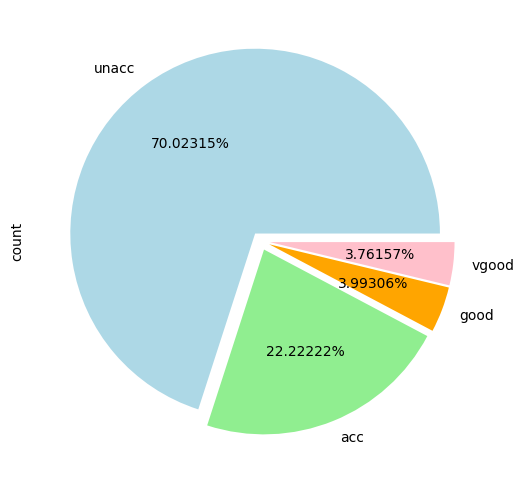

In [7]:
#2-3 예제 데이터셋 분포
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%', 
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

In [8]:
#2-4 데이터를 범주형 타입으로 변환
categorical_colums=['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety'] #car_evaluation 데이터 컬럼

for category in categorical_colums:
    dataset[category] = dataset[category].astype('category') #astype() 메서드를 이용하여 데이터를 범주형으로 변경

price = dataset['price'].cat.codes.values #넘파일 배열
maint = dataset['maint'].cat.codes.values #넘파일 배열
doors = dataset['doors'].cat.codes.values #넘파일 배열
persons = dataset['persons'].cat.codes.values #넘파일 배열
lug_capacity = dataset['lug_capacity'].cat.codes.values #넘파일 배열
safety = dataset['safety'].cat.codes.values #넘파일 배열

cateogrical_data = np.stack([price, maint, doors, persons, lug_capacity, safety], 1)
cateogrical_data[:10]


array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

In [9]:
#2-5. 배열을 텐서로 변환
cateogrical_data = torch.tensor(cateogrical_data, dtype=torch.int64)
cateogrical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [10]:
#2-6 레이블(정답)으로 사용할 컬럼을 텐서로 변환
outputs = pd.get_dummies(dataset.output) #넘파일 배열로 변환
outputs = outputs.values
outputs = torch.tensor(outputs).flatten() #1차원 텐서로 변환

print(cateogrical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [11]:
data = {
    'gender' : ['male', 'female', 'male'],
    'weight' : [72,55,68],
    'nation' : ['Japan', 'Korea', 'Australia']
}

df = pd.DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Australia


In [12]:
#get_dummies
pd.get_dummies(df) 

,weight,gender_female,gender_male,nation_Australia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


In [13]:
#2-7 범주형 컬럼을 N차원으로 전환
cateogorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_colums]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in cateogorical_column_sizes]

print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [22]:
#2-8 데이터 셋 분리
total_records = 1728
test_records = int(total_records * 0.2) # 전체 데이터 중 20를 테스트 용도로 사용

categorical_train_data = cateogrical_data[:total_records - test_records]
categorical_test_data = cateogrical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [24]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [70]:
#2-10 모델의 네트워크 생성

class Model(nn.Module): #class(클래스)형태로 구현되는 모델은 nn.Model로 상속받음
    #파라미터(1)-self (자기 자신을 의미) 
    #파라미터(2)-embedding_size : 범주형 컬럼의 임베딩 크기 (/2)
    #파라미터(3)-output_size : 출력층의 크기
    #파라미터(4)-layers : 모든 계층에 대한 목록
    #파라미터(5)-p : 드롭아웃(기본값 0.5) *과적합을 막기 위한 신경망의 뉴런 일부를 에포크마다 무작위로 끔 
    def __init__(self, embedding_size, output_size, layers, p=0.4): #__init__()은 모델에서 사용될 파라미터 및 신경망을 초기화할 용도로 사용
        super().__init__() # 부모 클래스(nn.Model)에 접근하기 위해 사용

        #모델에 네트워크 계층을 구축하기 위해 for문을 이용하여 각 계층을 all_layers에 추가 
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size]) 
        self.embedding_dropout = nn.Dropout(p)
        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols #입력층의 크기를 찾기 위해 범주형 컬럼 개수를 input_size 변수에 저장

        for i in layers: 

            #선형 계층(linear layers) 입력데이터에 선형 변환을 진행한 결과 
            all_layers.append(nn.Linear(input_size, i)) #y = Wx + b (y: 선형 계층의 출력 값, W : 가중치, x 입력 값, b: 바이어스(핛습을 통해 스스로 결과를 위아래로 조정))
            
            all_layers.append(nn.ReLU(inplace=True)) #활성화 함수
            all_layers.append(nn.BatchNorm1d(i)) #배치 정규화(batch normalization)
            all_layers.append(nn.Dropout(p)) #과적합 방지 사용
            input_size = i
            
        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers) #신경망의 모든 계층이 순차적으로 실행되도록 모든 계층에 대한 목록(all_layers)을 nn.Sequential 클래스로 전달

        #학습데이터를 받아 연산 진행 (모델 객체를 데이터와 함께 호출하면 자동 실행 
    def forward(self, x_cateogrical):
        embeddings = []
        for i, e in enumerate(self.all_embeddings):
            embeddings.append(e(x_cateogrical[:, i]))
            
        x = torch.cat(embeddings, 1) #넘파이의 concatenate(서로 다른 크기도 합칠 수 있음 axis = 0) 와 같지만 대상이 텐서

        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

#2-11 Model 클래스의 객체 생성
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [71]:
#2-12 모델의 파라미터 정의
# 모델 훈련시키기 전에 손실 함수(정답과 비교)와 옵티마이저(조율)에 대해 정의해야 함
loss_function = nn.CrossEntropyLoss() #데이터 분류용 크로스 엔트로피(cross entrop) 손실 함수 사용
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #lr : 학습률 , 옵티마이저의 경우 Adam 사용

In [72]:
#2-13 CPU/GPU 사용 지정
if torch.cuda.is_available(): #파이토치의 경우 GPU에 최적화된  딥러닝 프레임워크
    device = torch.device('cuda') #GPU가 있다면 GPU 사용
else :
    device = torch.device('cpu') #GPU가 없다면 CPU 사용

In [78]:
#2-14 모델 학습 
epochs = 500 #500번 반복
aggreated_losses = []

train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs): #for문은 500번 반복되며 각 반복마다 손실 함수가 오차를 계산함
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggreated_losses.append(single_loss) #반복할 때마다 오차를 aggregated_losses에 추가

    if i%25 == 1:
        print(f'epoch: {i:3} loss : {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward() #가중치를 업데이트하기 위해 손실 함수의 backward()/역전파 메소드 호출
    optimizer.step() #옵티마이저 함수 step() 메소드를 이용해 기울기 업데이트

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}') #오차가 25에포크마다 호출
        

epoch:   1 loss : 0.57958961
epoch:  26 loss : 0.57054937
epoch:  51 loss : 0.57200086
epoch:  76 loss : 0.56851929
epoch: 101 loss : 0.56264865
epoch: 126 loss : 0.57367074
epoch: 151 loss : 0.56836838
epoch: 176 loss : 0.57913584
epoch: 201 loss : 0.56582046
epoch: 226 loss : 0.56914902
epoch: 251 loss : 0.56102163
epoch: 276 loss : 0.56213206
epoch: 301 loss : 0.56900370
epoch: 326 loss : 0.56347102
epoch: 351 loss : 0.56580138
epoch: 376 loss : 0.56734788
epoch: 401 loss : 0.55818701
epoch: 426 loss : 0.55942315
epoch: 451 loss : 0.56253272
epoch: 476 loss : 0.56126976
epoch: 500 loss: 0.5562182069


In [79]:
#2-15 테스트 데이터셋으로 모델 예측
test_outputs = test_outputs.to(device=device, dtype=torch.int64)

with torch.no_grad():
    y_val = model(categorical_test_data)
    loss = loss_function(y_val, test_outputs)
print(f'loss: {loss : 8f}')

loss:  0.551631


In [80]:
#2-16 모델의 예측 확인
print(y_val[:5])

tensor([[ 3.1863,  2.0636, -3.8986, -4.2422],
        [ 3.6523,  2.3964, -4.8949, -5.1917],
        [ 3.6867,  2.2120, -4.5639, -5.1674],
        [ 3.6566,  2.3646, -5.2962, -5.6905],
        [ 2.7382,  1.6937, -4.1418, -4.0688]])


In [82]:
#2-17 가장 큰 값을 갖는 인덱스 확인
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [83]:
#2-18 테스트 데이터셋을 이용한 정확도 확인
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print('-----------------------------------')
print(classification_report(test_outputs, y_val))
print('-----------------------------------')
print(accuracy_score(test_outputs, y_val))

[[257   2]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      0.99      0.86       259
           1       0.33      0.01      0.02        86

    accuracy                           0.75       345
   macro avg       0.54      0.50      0.44       345
weighted avg       0.65      0.75      0.65       345

0.7478260869565218
